In [ ]:
# Importing preprocessed df_pir
import pandas as pd
df_pir = pd.read_csv('df_pir.csv')

# For XPIR

## For Patient Queries Database

In [ ]:
#df_pir has two string columns (income, edu) that need to be encoded to numbers before binary packing
income_map = {'under $11k': 0, '$11-$25k': 1, '$25-$50k': 2, '>$50k': 3}
df_pir['income'] = df_pir['income'].map(income_map).fillna(-1)
df_pir['edu'] = pd.to_numeric(df_pir['edu'], errors='coerce').fillna(-1)

In [ ]:
impute_vals = {
    'alb': 3.5, 'pafi': 333.3, 'bili': 1.01, 'crea': 1.01,
    'bun': 6.51, 'wblc': 9.0, 'urine': 2502.0
}
df_pir.fillna(impute_vals, inplace=True)
df_pir.fillna(0.0, inplace=True)  # remaining NaNs → 0

         scoma   meanbp      hrt     resp     temp     pafi      alb     bili  \
count  9105.00  9105.00  9105.00  9105.00  9105.00  9105.00  9105.00  9105.00   
mean     12.06    84.55    97.16    23.33    37.10   235.56     2.93     2.08   
std      24.64    27.69    31.56     9.57     1.25    94.87     0.70     4.56   
min       0.00     0.00     0.00     0.00    31.70    12.00     0.40     0.10   
25%       0.00    63.00    72.00    18.00    36.20   180.00     2.70     0.60   
50%       0.00    77.00   100.00    24.00    36.70   224.00     2.90     0.90   
75%       9.00   107.00   120.00    28.00    38.20   274.25     3.10     1.30   
max     100.00   195.00   300.00    90.00    41.70   890.38    29.00    63.00   

          crea      sod  ...  dzgroup       ca  diabetes  dementia      age  \
count  9105.00  9105.00  ...  9105.00  9105.00    9105.0   9105.00  9105.00   
mean      1.77   137.57  ...     2.23     0.93       0.2      0.03    62.65   
std       1.68     6.03  ...     

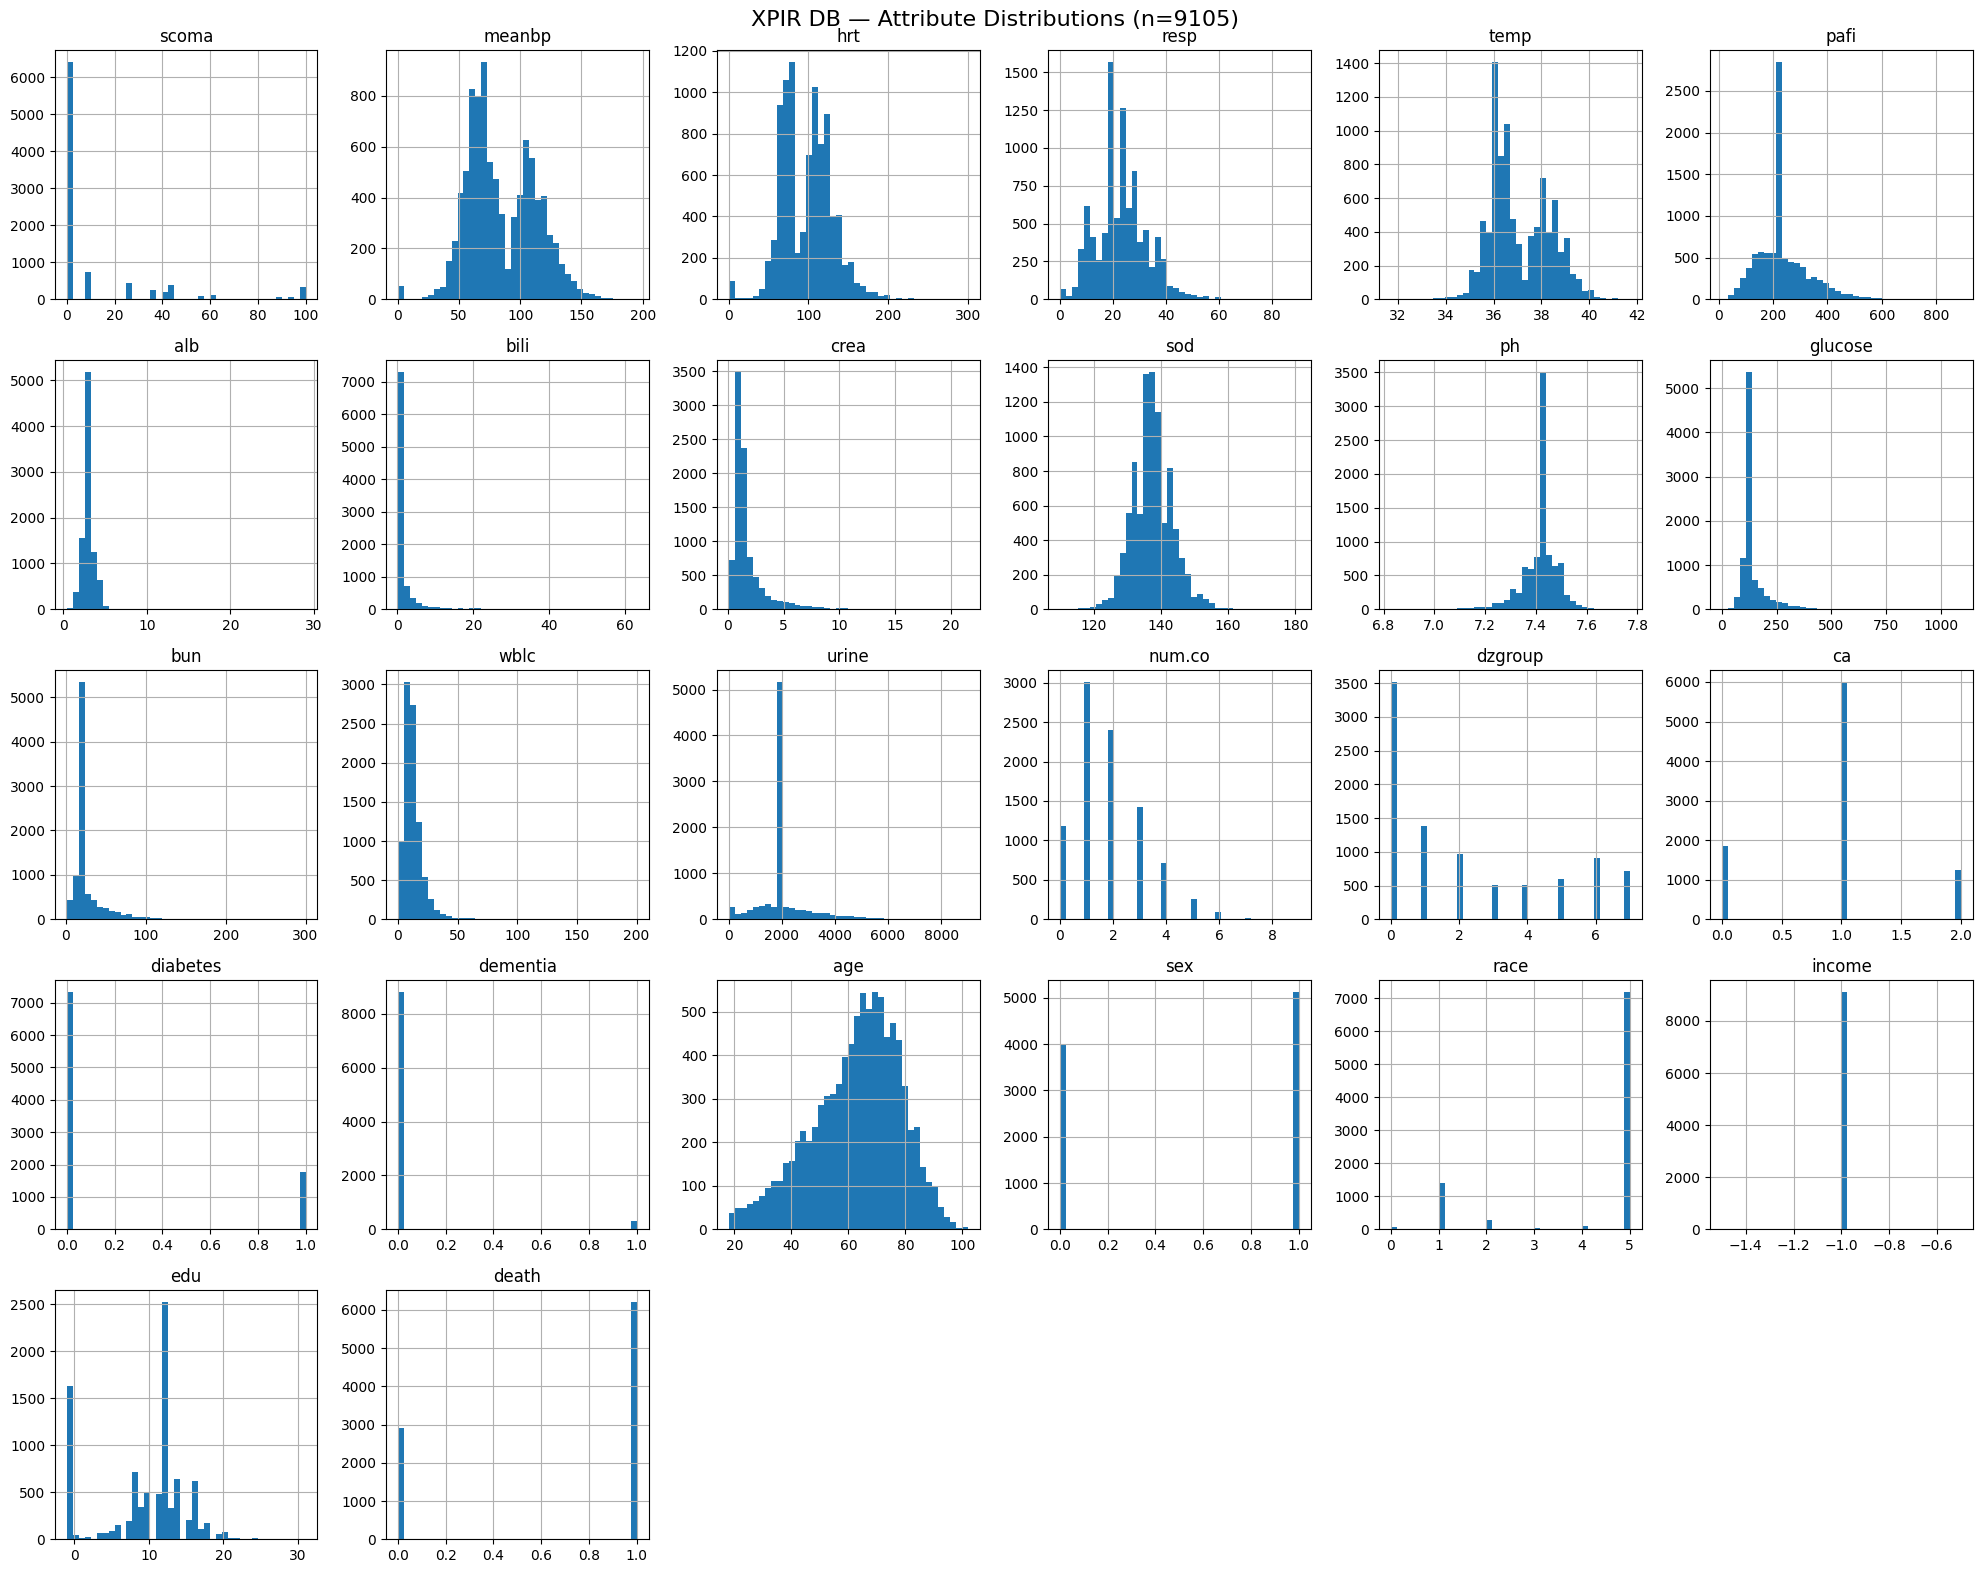

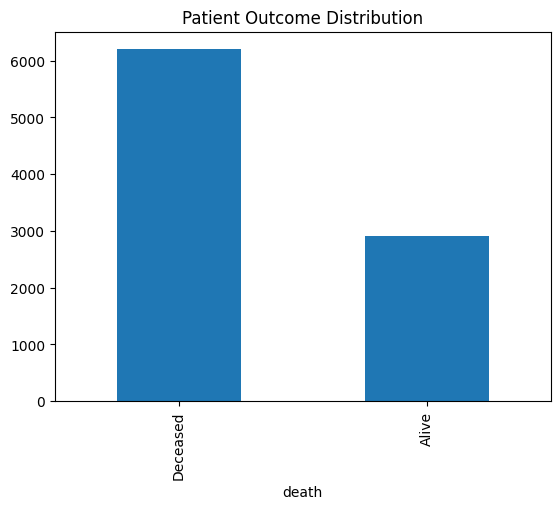

In [ ]:
import matplotlib.pyplot as plt

# Quick stats
print(df_pir.describe().round(2))

# Distribution plots for all 26 columns
df_pir.hist(bins=40, figsize=(20, 16), layout=(5, 6))
plt.suptitle("XPIR DB — Attribute Distributions (n=9105)", fontsize=16)
plt.tight_layout()
plt.savefig('/content/xpir_db_stats.png', dpi=150)
plt.show()

# Death outcome breakdown
df_pir['death'].value_counts().rename({0:'Alive', 1:'Deceased'}).plot.bar()
plt.title("Patient Outcome Distribution")
plt.show()

In [ ]:
import struct, os

#Each row is packed as 26 double (float64) values = 208 bytes per file
xpir_db_path = '/content/xpir_db'
os.makedirs(xpir_db_path, exist_ok=True)

for i, row in df_pir.iterrows():
    record_bytes = struct.pack('26d', *row.values.astype(float))
    with open(os.path.join(xpir_db_path, str(i)), 'wb') as f:
        f.write(record_bytes)

print(f"Written {len(df_pir)} binary files to {xpir_db_path}")

Written 9105 binary files to /content/xpir_db


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/xpir_db', 'zip', '/content/xpir_db')
files.download('/content/xpir_db.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## For Researcher queries

In [ ]:
import pandas as pd
import numpy as np
import struct, os, json
from ucimlrepo import fetch_ucirepo

support2 = fetch_ucirepo(id=880)
X = support2.data.features
y = support2.data.targets
df = pd.concat([X, y], axis=1)

RESEARCH_COLS = ['meanbp','hrt','resp','temp','pafi','alb','bili',
                 'crea','sod','ph','glucose','bun','wblc','urine',
                 'scoma','age','death','diabetes','dementia']

impute = {'alb':3.5,'pafi':333.3,'bili':1.01,'crea':1.01,
          'bun':6.51,'wblc':9.0,'urine':2502.0}

records = []
index_map = {}
idx = 0

def add_record(label, subset):
    global idx
    group = subset[RESEARCH_COLS].copy().fillna(impute).fillna(0.0)
    stats = []
    for col in RESEARCH_COLS:
        stats.append(float(group[col].mean()))
        stats.append(float(group[col].std()))
        stats.append(float(len(group)))
    records.append(stats)
    index_map[str(idx)] = label
    idx += 1

# 1. Disease groups (8 records)
for disease in sorted(df['dzgroup'].dropna().unique()):
    add_record(f"Disease: {disease}", df[df['dzgroup']==disease])

# 2. Disease × Outcome (16 records)
for disease in sorted(df['dzgroup'].dropna().unique()):
    add_record(f"Disease: {disease} | Survived",
               df[(df['dzgroup']==disease) & (df['death']==0)])
    add_record(f"Disease: {disease} | Deceased",
               df[(df['dzgroup']==disease) & (df['death']==1)])

# 3. Age brackets (5 records)
age_bins = [(18,40,'18-40'),(41,60,'41-60'),(61,70,'61-70'),
            (71,80,'71-80'),(81,120,'81+')]
for lo, hi, label in age_bins:
    add_record(f"Age: {label}",
               df[(df['age']>=lo) & (df['age']<hi)])

# 4. BP severity (3 records)
add_record("BP: Normal (<80 mmHg)",   df[df['meanbp']<80])
add_record("BP: Elevated (80-100)",   df[(df['meanbp']>=80)&(df['meanbp']<=100)])
add_record("BP: Hypertensive (>100)", df[df['meanbp']>100])

# 5. Comorbidities (4 records)
add_record("Comorbidity: Diabetes",   df[df['diabetes']==1])
add_record("Comorbidity: No Diabetes",df[df['diabetes']==0])
add_record("Comorbidity: Dementia",   df[df['dementia']==1])
add_record("Comorbidity: No Dementia",df[df['dementia']==0])

# 6. Cancer status (3 records)
add_record("Cancer: None",        df[df['ca']=='no'])
add_record("Cancer: Yes",         df[df['ca']=='yes'])
add_record("Cancer: Metastatic",  df[df['ca']=='metastatic'])

print(f"Total research records: {len(records)}")
print("\nFull Research Index:")
for i, name in index_map.items():
    print(f"  [{i}]  {name}")

Total research records: 39

Full Research Index:
  [0]  Disease: ARF/MOSF w/Sepsis
  [1]  Disease: CHF
  [2]  Disease: COPD
  [3]  Disease: Cirrhosis
  [4]  Disease: Colon Cancer
  [5]  Disease: Coma
  [6]  Disease: Lung Cancer
  [7]  Disease: MOSF w/Malig
  [8]  Disease: ARF/MOSF w/Sepsis | Survived
  [9]  Disease: ARF/MOSF w/Sepsis | Deceased
  [10]  Disease: CHF | Survived
  [11]  Disease: CHF | Deceased
  [12]  Disease: COPD | Survived
  [13]  Disease: COPD | Deceased
  [14]  Disease: Cirrhosis | Survived
  [15]  Disease: Cirrhosis | Deceased
  [16]  Disease: Colon Cancer | Survived
  [17]  Disease: Colon Cancer | Deceased
  [18]  Disease: Coma | Survived
  [19]  Disease: Coma | Deceased
  [20]  Disease: Lung Cancer | Survived
  [21]  Disease: Lung Cancer | Deceased
  [22]  Disease: MOSF w/Malig | Survived
  [23]  Disease: MOSF w/Malig | Deceased
  [24]  Age: 18-40
  [25]  Age: 41-60
  [26]  Age: 61-70
  [27]  Age: 71-80
  [28]  Age: 81+
  [29]  BP: Normal (<80 mmHg)
  [30]  BP: El

In [ ]:
research_db_path = '/content/xpir_research_db'
os.makedirs(research_db_path, exist_ok=True)

n_vals = len(records[0])
fmt = f'{n_vals}d'
RECORD_SIZE = 512  # padded

for i, row in enumerate(records):
    record_bytes = struct.pack(fmt, *row)
    record_bytes = record_bytes.ljust(RECORD_SIZE, b'\x00')
    with open(os.path.join(research_db_path, str(i)), 'wb') as f:
        f.write(record_bytes)

with open('/content/research_index_map.json', 'w') as f:
    json.dump(index_map, f, indent=2)

print(f"Written {len(records)} records of {RECORD_SIZE} bytes each")
print(f"Total DB: {len(records) * RECORD_SIZE} bytes")

Written 39 records of 512 bytes each
Total DB: 19968 bytes


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/xpir_research_db', 'zip', '/content/xpir_research_db')
files.download('/content/xpir_research_db.zip')
files.download('/content/research_index_map.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>